In [1]:
from genData.nba import NBADataCollection
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from syslibutils import *

In [ ]:
sampling_rate = 15
start_date="2020-01-01"
filepath = "../data/nba/"

nba = NBADataCollection(sampling_rate=sampling_rate, start_date=start_date, filepath=filepath)

In [ ]:
data = nba.get_full_data()
data.to_csv(f"{filepath}nba_full_data_{sampling_rate}.csv", index=False)

print(data.shape)
data.head()

In [33]:
total_seconds = int(60*12*4)
total_timepoints = int((60/sampling_rate)*12*4)
print(f"Total timepoints in a game with sampling rate {sampling_rate} seconds: {total_timepoints}")
print(f"Total seconds in a game: {total_seconds}")

Y = data.iloc[:,1:1+total_timepoints]
Y = Y.astype(float) # the final matrix Y is ready for sc

Total timepoints in a game with sampling rate 30 seconds: 96
Total seconds in a game: 2880


# singular value spectrum for Y and Y_centered

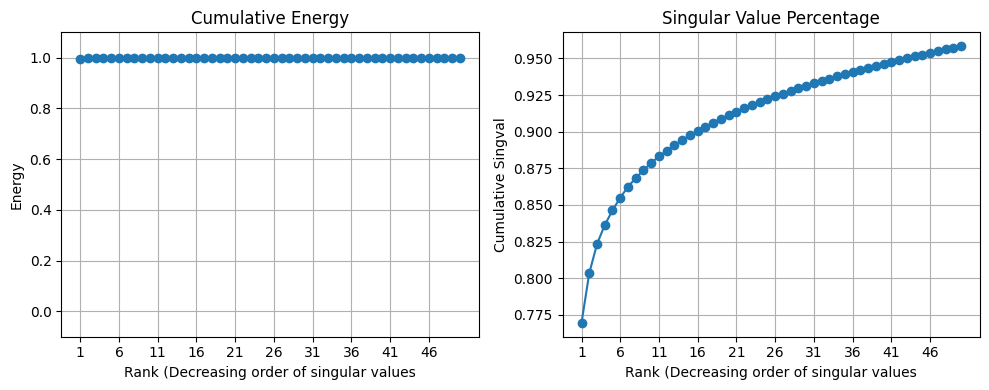

In [34]:
s = singval_test(pd.DataFrame(Y))

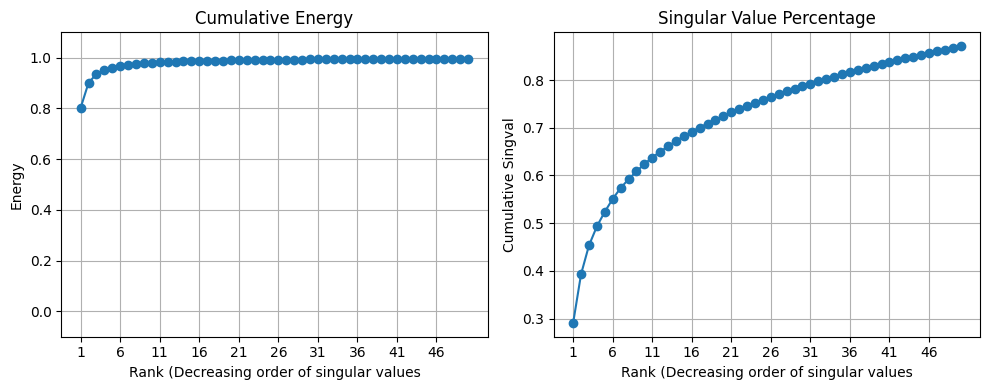

In [ ]:
Y_mean = Y.mean(axis=0)
Y_centered = Y - Y_mean

s = singval_test(pd.DataFrame(Y_centered))

# maybe use centered data and test d=2, 3, 5, 8, etc.
